### 영상처리를 위한 딥러닝 - 2

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## fashion_mnist 


holdout
- stratification
- 분할 비율 

In [3]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

In [4]:
np.unique(y_train, return_counts=True) # 층화(stratified) 분류 이미 되어있음 

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000],
       dtype=int64))

데이터셋 특징 
- mnist와 동일하게 배경이 없도록 전처리함
- center-alignede되어 있고 이미지로 꽉차 있음
- 데이터의 위치를 중점으로 지정
    - feature extraction이 쉬워 연산량이 많은 CNN을 안 써도 어느 정도 성능이 확보됨 
> 오컴의 면도날 
 성능이 동일하면 모델은 간단할 수록 좋음   
 https://ko.wikipedia.org/wiki/%EC%98%A4%EC%BB%B4%EC%9D%98_%EB%A9%B4%EB%8F%84%EB%82%A0

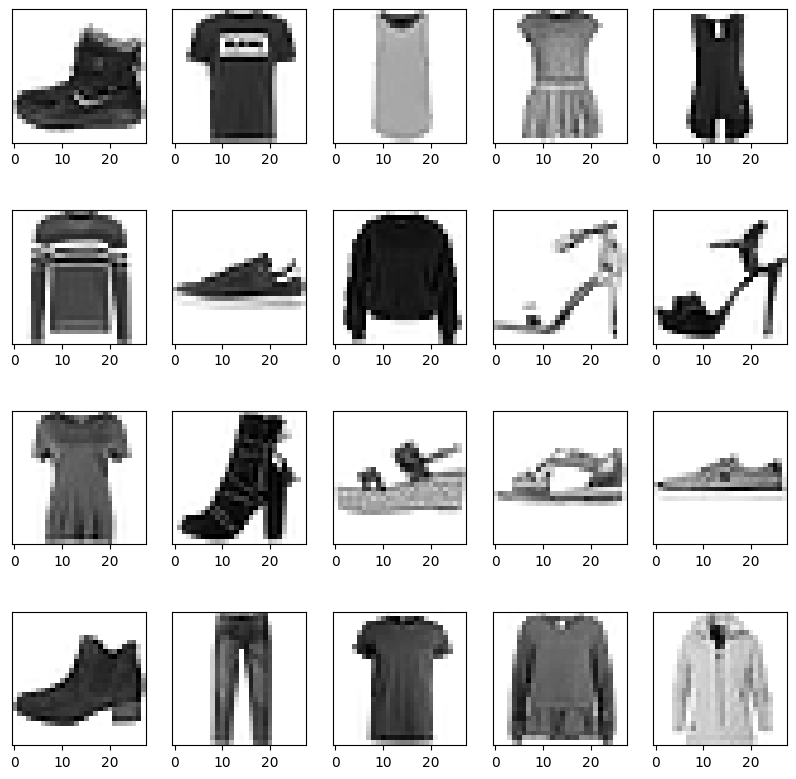

In [5]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(4,5,i+1) #  index로 이미지 
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
plt.show()

### activation
- 비선형 함수를 사용하여 원래 데이터를 마지막에 선형분류가 가능하도록 왜곡함
> Colah's blog post : https://colah.github.io/posts/2015-09-NN-Types-FP/
    - manifold learning(비선형 차원 축소)
- hidden layers의 activation function 필수
- sigmoid : 레이어가 많아지면서 미분값이 계속 0 에 가까워지면서 gradient vanishing 문제 생김
- relu (rectified) : 0보다 작으면 0, 크면 그값 그대로 
- softmax : 값을 0~1사이로 확률 값처럼 만들어줌

### activation 인자
- 문자열
    - 기본 default만 사용 가능 
        - 예 'relu'
-  함수
    - 소문자
    - tf의 keras.activations , nn package에 있음
    - functional paradigm 
    - 함수의 기본값 바꾸기 가능 
        - 예. tf.nn.relu
    - 함수는 first class function으로 객체로 쓰임
- functools partial로 가능 (decorator처럼 씀)하지만 복잡

In [6]:
tf.keras.activations.softmax

<function keras.activations.softmax(x, axis=-1)>

In [7]:
tf.nn.softmax

<function tensorflow.python.ops.nn_ops.softmax_v2(logits, axis=None, name=None)>

In [8]:
tf.keras.activations.softmax is tf.nn.softmax

False

### layer
- layer많으면 데이터 많이 필요하고  layer가 많고 데이터가 적으면 overfitting 발생
- 앞의 layer 가 feature extraction
    - Dense 1차원 
    - Flatten 2차원 형태의 데이터를 받으면 1차원화
    - convolution은 3차원 형태의 데이터 받음

In [9]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu') ,
    tf.keras.layers.Dense(64, activation=tf.nn.relu) ,
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________


### compile 
학습전략
#### loss
- 문제 도메인에 따라 정의된것을 사용
    - 실제값과 예측값을 어떻게 정의하는지에 따라 결정
-  문자열:
    -  오타 조심
    - 'sparse_categorical_crossentropy'
- 소문자: 함수
    - snake 방식
    - sparse_categorical_crossentropy
- 대문자 : 객체(Camel 방식)
    - 상속, 인자값 바꾸기 가능 
    - 인스턴스화
    - SparseCategoricalCrossentropy()
#### optimizer
- gradient vanishing을 어떤 알고리즘으로 효율적으로 해결할지를 선택
#### metrics
- 성능 비교 기준

In [11]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer='adam',metrics=['accuracy'])

In [12]:
dir(tf.keras.losses.SparseCategoricalCrossentropy())

['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_allow_sum_over_batch_size',
 '_fn_kwargs',
 '_get_reduction',
 '_keras_api_names',
 '_keras_api_names_v1',
 '_name_scope',
 '_set_name_scope',
 'call',
 'fn',
 'from_config',
 'get_config',
 'name',
 'reduction']

In [13]:
type(tf.keras.losses.SparseCategoricalCrossentropy) # 객체 

type

In [14]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [15]:
model.compile(loss='sparse_categorical_crossentropy'
             , optimizer='adam',metrics=['accuracy'])

### 정규화 비교
- -1 ~ 1사이 ,  0 ~ 1 사이 loss차이 별로 없으나 정규화 안한 데이터와의 loss차이는 큼

In [16]:
X_train128 = X_train/128 - 1
X_test128 = X_test/128 - 1

X_train255 = X_train/255
X_test255 = X_test/255

In [17]:
model.fit(X_train,y_train,epochs=5) # 정규화 안한 경우

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 1.9231 - accuracy: 0.7057
Epoch 2/5
1875/1875 [==============================] - 5s 2ms/step - loss: 0.6958 - accuracy: 0.7724
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.6419 - accuracy: 0.7927
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.6055 - accuracy: 0.8038
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.5842 - accuracy: 0.8082


In [18]:
model.fit(X_train128,y_train,epochs=5)  # -1 ~ 1 사이

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.4882 - accuracy: 0.8240
Epoch 2/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3787 - accuracy: 0.8621
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3516 - accuracy: 0.8706
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3318 - accuracy: 0.8783
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3137 - accuracy: 0.8843


In [19]:
model.fit(X_train255,y_train,epochs=5) # 0~1사이가 약간 더 좋으나 유의미하지 않음

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3209 - accuracy: 0.8856
Epoch 2/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2965 - accuracy: 0.8921
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2822 - accuracy: 0.8957
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2722 - accuracy: 0.8990
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2627 - accuracy: 0.9032


### tensorflow이용한 이미지 전처리
- 내부적으로 PIL로 구현 되어 있음 
    - load_img(이미지)
        - 이미지 불러오기 
       - repr 자체가 이미지로 나옴
    - save_img(path, 3차원 이미지)
        - directory 설정 안하면 현재 작업하는 디렉토리에 저장됨
        - 기본 3차원, jpg
    - array_to_img
        - array에서 PIL기반 이미지
    - img_to_array 
        - 이미지에서 Numpy기반 이미지

In [21]:
from tensorflow.keras.preprocessing.image import load_img,save_img,array_to_img,img_to_array

In [22]:
save_img('boot.jpg',X_train255[0].reshape(28,28,1)) # 확장자 적용됨

In [23]:
img = load_img('boot.jpg')  # PIl.open()과 동일
img

- repr 자체가 이미지로 나옴
- PIL 로 처리됨

In [24]:
type(img)  # # PIL기반 jpg 확장자 파일 

PIL.Image.Image

In [25]:
from PIL import Image
img2=Image.open('boot.jpg')  #동일함
print(type(img2))  # JpegImageFile
img2

<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [26]:
img_to_array(img) # numpy array

array([[[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 5.,  5.,  5.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [13., 13., 13.],
        [ 3.,  3.,  3.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 8.,  8.,  8.],
        [ 0.,  0.,  0.]],

       ...,

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 5.,  5.,  5.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[11., 11., 11.],
        [ 1.,  1.,  1.],
        [ 5.,  5.,  5.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 4.,  4.,  4.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]]

간단한 이미지 처리는 keras.preprocessing.image로 처리

In [27]:
print(np.array(img).shape)
np.array(img) # Numpy로 array변경한 것과 동일

(28, 28, 3)


array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 5,  5,  5],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [13, 13, 13],
        [ 3,  3,  3]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 8,  8,  8],
        [ 0,  0,  0]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 5,  5,  5],
        [ 0,  0,  0],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [ 1,  1,  1],
        [ 5,  5,  5],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 4,  4,  4],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)

In [28]:
print(img_to_array(img2).shape)
img_to_array(img2) #numpy array

(28, 28, 1)


array([[[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [ 17.],
        [  0.],
        [  3.],
        [  7.],
        [  1.],
        [  0.],
        [  2.],
        [  7.],
        [  3.],
        [  0.],
        [  0.],
        [  5.],
        [  1.],
        [  0.],
        [  0.],
        [  0.],
        [  5.],
        [  0.],
        [  0.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  4.],
        [  0.],
        [  7.],
        [  0.],
        [  6.],
        [  1.],
        [  6.],
        [  0.],
        [  1.],
        [ 15.],
        [  0.],
        [  0.],
        [  0.],
        [ 10.],
        [  6.],
        [  0.],
        [  0.],
        [ 13.],
        [  3.]],

       [[  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
        [  0.],
    

In [29]:
print(np.array(img2).shape)
np.array(img2)

(28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,  17,   0,   3,   7,
          1,   0,   2,   7,   3,   0,   0,   5,   1,   0,   0,   0,   5,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   7,   0,
          6,   1,   6,   0,   1,  15,   0,   0,   0,  10,   6,   0,   0,
         13,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   7,   0,
          4,   0,   0,  22,   0,   0,  10,   5,   0,   0,   0,   1,   0,
          8,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   6,   0,   1,   3,   2,
          3,   0,  25,  71,   5,   0,   8,   0,   0,   7,   9,  11,   3,
          2,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   1,   0,   9,
          1,  39, 126, 130,  76,  40,  16,   0,   0,  12,   0,   0,   6,
          0,  10],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   9,   3,   0,   0,
          0,  98, 213, 161, 147, 140, 110,  42,   0,   0,   0,   6,  22,
         11,   3],
       [  

In [30]:
img.mode,img.format,img.size  # PIL metadata 

('RGB', None, (28, 28))

In [31]:
import inspect
print(inspect.getsource(save_img)) # PIL로 구현되어 있음

@keras_export("keras.utils.save_img", "keras.preprocessing.image.save_img")
def save_img(path, x, data_format=None, file_format=None, scale=True, **kwargs):
    """Saves an image stored as a Numpy array to a path or file object.

    Args:
        path: Path or file object.
        x: Numpy array.
        data_format: Image data format, either `"channels_first"` or
          `"channels_last"`.
        file_format: Optional file format override. If omitted, the format to
          use is determined from the filename extension. If a file object was
          used instead of a filename, this parameter should always be used.
        scale: Whether to rescale image values to be within `[0, 255]`.
        **kwargs: Additional keyword arguments passed to `PIL.Image.save()`.
    """
    if data_format is None:
        data_format = backend.image_data_format()
    img = array_to_img(x, data_format=data_format, scale=scale)
    if img.mode == "RGBA" and (file_format == "jpg" or file_format == "j

#### evaluate
 - 성능 비교
 - fit처럼 학습하는게 아닌 predict예측을 하여 epochs없음 
 - 각 모델 변경해서 비교


return 2개
- loss
- compile(metrics=[]) 에서 지정한 기준
    - accuracy

In [32]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 73.7307 - accuracy: 0.8380


[73.730712890625, 0.8379999995231628]

In [33]:
model.predict(X_test)[1]

313/313 [==============================] - 0s 1ms/step


array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [34]:
np.sum(model.predict(X_test)[1])  #softmax는 확률처럼 계산하여 합치면 1

313/313 [==============================] - 1s 2ms/step


1.0

In [35]:
np.argmax(model.predict(X_test)[1]) #가장 큰 index 2번째

313/313 [==============================] - 0s 1ms/step


2

### one-hot encoding
- to_categorical
    - label encoding된 y를 one-hot encoding함
    - tf,pandas, scikit-learn
    - 구분자 역할을 하므로 label encodin과 성능 차이는 없음

In [36]:
from tensorflow.keras.utils import to_categorical

In [37]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()
y_train,y_train.shape

(array([9, 0, 0, ..., 3, 0, 5], dtype=uint8), (60000,))

In [38]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_train,y_train.shape

(array([[0., 0., 0., ..., 0., 0., 1.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 (60000, 10))

In [39]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu') ,
    tf.keras.layers.Dense(64, activation=tf.nn.relu) ,
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [40]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 7s 4ms/step - loss: 2.1808 - accuracy: 0.7402
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.6252 - accuracy: 0.7997
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.5803 - accuracy: 0.8083
Epoch 4/5
1875/1875 [==============================] - 5s 2ms/step - loss: 0.5458 - accuracy: 0.8162
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.5029 - accuracy: 0.8266


In [41]:
model.predict(X_test)[1]

313/313 [==============================] - 1s 2ms/step


array([8.9075125e-04, 2.2790055e-06, 9.4072580e-01, 1.6122746e-04,
       9.4909910e-03, 2.7289792e-11, 4.7602315e-02, 1.7802797e-16,
       1.1266279e-03, 7.8216751e-18], dtype=float32)

In [42]:
np.argmax(model.predict(X_test)[1]) # 동일하게 2번째 

313/313 [==============================] - 1s 2ms/step


2

In [43]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.5442 - accuracy: 0.8134


[0.544195830821991, 0.8133999705314636]

In [44]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu') ,  # 64 ---> 128 
    tf.keras.layers.Dense(128, activation='relu') ,  # 64 ---> 128
    tf.keras.layers.Dense(10, activation='softmax') # 마지막 결과 값을 확률값처럼 나오게 바꿈(optional)
])

model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy'])

In [45]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 7s 3ms/step - loss: 2.0605 - accuracy: 0.7247
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.6789 - accuracy: 0.7757
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.6207 - accuracy: 0.7942
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.5902 - accuracy: 0.8047
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.5170 - accuracy: 0.8270


In [46]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.5576 - accuracy: 0.8210


[0.5575503706932068, 0.8209999799728394]

딥러닝: 레이어가 많은 multi-layer perceptron
- 중요도 : layer > node
- layer지나갈때마다 데이터 공간을 왜곡시키기 때문에 layer가 더 중요함

In [47]:
model.predict(X_test)[1]

313/313 [==============================] - 1s 2ms/step


array([4.7364771e-05, 2.9230945e-05, 9.5928264e-01, 3.9619063e-06,
       8.4682507e-03, 1.3869566e-18, 3.2165654e-02, 5.7334389e-20,
       2.8840498e-06, 1.2112692e-15], dtype=float32)

In [48]:
np.argmax(model.predict(X_test)[1]) # 동일하게 2번째 

313/313 [==============================] - 1s 2ms/step


2

### 하이퍼파라미터 튜닝
- 모델 선택후 모델의 하이퍼파라미터를 비교 선택해야하는데 수동으로 하면 오래걸리므로 자동화 하는 방법이 있다
    - scikit 의 gridsearchCV
    - Keras의 Keras Tuner
        - 후자는 나중에, https://www.tensorflow.org/tutorials/keras/keras_tuner?hl=ko

#### gridsearchCV
- 자동화된 하이퍼 파라미터 찾아서 최적화
- scikit-learn, keras 연동 가능 
    - keras GPU 지원하기 때문에 연동하면 scikit가능
    - KerasClassifier,  KerasRegressor 객체 인스턴스화 하여 사용 
####  KerasClassifier
- instance화
- = KerasClassifier( build_fn)
- classification 모델을 함수를 인자로 받음 

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

In [51]:
def build_model( ): 
    
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam' ,metrics=['accuracy'])
    
    return model

In [52]:
def build_model(optimizer='adam' ): 
    
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer= optimizer ,metrics=['accuracy'])
    
    return model

In [53]:
kc = KerasClassifier(build_fn=build_model) # 함수로 받음

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\2938288046.py:1: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc = KerasClassifier(build_fn=build_model) # 함수로 받음


In [54]:
kc.fit(X_train,y_train,epochs=3)  # GPU 지원 됨

Epoch 1/3
1875/1875 [==============================] - 5s 3ms/step - loss: 3.0658 - accuracy: 0.6970
Epoch 2/3
1875/1875 [==============================] - 5s 2ms/step - loss: 0.6534 - accuracy: 0.7751
Epoch 3/3
1875/1875 [==============================] - 5s 2ms/step - loss: 0.6182 - accuracy: 0.7836


In [55]:
tf.keras.backend.clear_session()

In [56]:
# ! pip install scikeras
# from scikeras.wrappers import KerasClassifier, KerasRegressor
kc=KerasClassifier( build_fn=build_model) 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\3584946843.py:3: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc=KerasClassifier( build_fn=build_model)


In [57]:
grid=GridSearchCV(kc, param_grid={'optimizer':['adam', 'rmsprop','adadelta']} )

In [58]:
# GPU 지원됨
grid.fit(X_train,y_train,epochs=1)  # cross validaton까지 함 , 3개 파라메터 * 5번 split(cv) -> 15회 학습
                                    # cv=None to use the default 5-fold cross validation

1875/1875 [==============================] - 6s 3ms/step - loss: 3.1753 - accuracy: 0.6915


,estimator,<keras.wrappe...002488AFCABC0>
,param_grid,"{'optimizer': ['adam', 'rmsprop', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


cv_results_
- GridSearchCV 한 결과로  학습 속도, cross validation score 값보여줌

adam > rmsprop >adadelta 순서

In [59]:
import pandas as pd
pd.DataFrame(grid.cv_results_)  # adam or rmsprop이 제일 빠르고 score도 가장 좋음

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_optimizer,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.374190,0.424259,1.078984,0.276262,adam,{'optimizer': 'adam'},0.719500,0.693333,0.734500,0.721833,0.686833,0.711200,0.018099,2
1,5.365456,0.217501,1.062134,0.055276,rmsprop,{'optimizer': 'rmsprop'},0.754833,0.701500,0.732083,0.702250,0.728083,0.723750,0.020058,1
2,4.728728,0.261301,1.129672,0.129177,adadelta,{'optimizer': 'adadelta'},0.221000,0.243667,0.196250,0.278000,0.262667,0.240317,0.029140,3


In [60]:
grid.best_estimator_,  grid.best_index_, grid.best_params_, grid.best_score_
# 결과는 'adam' 혹은 'rmsprop'으로 나옴

(<keras.wrappers.scikit_learn.KerasClassifier at 0x2488b0f47f0>,
 1,
 {'optimizer': 'rmsprop'},
 0.7237499952316284)

In [61]:
def build_model(node=64): 
    model=tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(node, activation='relu') ,
        tf.keras.layers.Dense(10, activation='softmax') 
    ])
    model.compile(loss=tf.keras.losses.categorical_crossentropy
             , optimizer='adam',metrics=['accuracy']) # 'adam' 혹은 'rmsprop'으로
    
    return model

### keras.wrappers.scikit_learn
- \*\*sk_params keras의 인자 입력 받을수 있어 scikit과 분리하여 사용 가능 
- composition :객체지향에서 감싸서 한 기법
    - fit대신에 KerasClassifier에 epochs=3, validation_split  지정

In [62]:
# keras.wrappers
kc=KerasClassifier( build_fn=build_model, epochs=3, validation_split=0.2) #함수로 받음 
# scikit-learn  
grid=GridSearchCV(kc,param_grid={'node':[64,128,256,512]},cv=2)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22416\27152232.py:2: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  kc=KerasClassifier( build_fn=build_model, epochs=3, validation_split=0.2) #함수로 받음


In [63]:
grid.fit(X_train,y_train)  # cross validaton까지 함 , cv =2

Epoch 1/3
750/750 [==============================] - 3s 3ms/step - loss: 5.0424 - accuracy: 0.5957 - val_loss: 1.1984 - val_accuracy: 0.5855
Epoch 2/3
750/750 [==============================] - 2s 3ms/step - loss: 1.0269 - accuracy: 0.6274 - val_loss: 0.9823 - val_accuracy: 0.6403
Epoch 3/3
938/938 [==============================] - 2s 3ms/step - loss: 0.8675 - accuracy: 0.6666
Epoch 1/3
750/750 [==============================] - 2s 3ms/step - loss: 7.5336 - accuracy: 0.6182 - val_loss: 1.3630 - val_accuracy: 0.6157
Epoch 2/3
750/750 [==============================] - 2s 3ms/step - loss: 1.1246 - accuracy: 0.6346 - val_loss: 1.0771 - val_accuracy: 0.6630
Epoch 3/3
938/938 [==============================] - 4s 4ms/step - loss: 0.9260 - accuracy: 0.6846
Epoch 1/3
750/750 [==============================] - 4s 4ms/step - loss: 7.2303 - accuracy: 0.6847 - val_loss: 1.1920 - val_accuracy: 0.6883
Epoch 2/3
750/750 [==============================] - 3s 4ms/step - loss: 0.8573 - accuracy: 0.719

,estimator,<keras.wrappe...0024BF28BA6B0>
,param_grid,"{'node': [64, 128, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [64]:
pd.DataFrame(grid.cv_results_) # node 많을 수록 성능 좋음

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_node,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,7.402814,0.104409,3.197969,0.629347,64,{'node': 64},0.666567,0.684567,0.675567,0.009000,4
1,8.896868,0.444318,3.427518,0.171136,128,{'node': 128},0.780667,0.757367,0.769017,0.011650,3
2,8.933183,0.647195,3.095631,0.107600,256,{'node': 256},0.794300,0.801000,0.797650,0.003350,2
3,9.223816,0.004229,3.386469,0.349036,512,{'node': 512},0.788433,0.819700,0.804067,0.015633,1


In [65]:
grid.best_estimator_,  grid.best_index_, grid.best_params_, grid.best_score_
# 결과는 : 512

(<keras.wrappers.scikit_learn.KerasClassifier at 0x2488b032d70>,
 3,
 {'node': 512},
 0.8040666580200195)